# Tìm hiểu Mô hình Perceptron — lý thuyết và mô phỏng huấn luyện bằng tay

**Môn học:** Học máy nâng cao (ml_ad) · **Học viên:** Nguyễn Phương Anh Tú · **MSHV:** 2611328

**Đề bài** (nguyên văn từ slide "TÌM HIỂU MÔ HÌNH PERCEPTRON"):
1. Thường được dùng để giải quyết bài toán gì?
2. Vì sao gọi mô hình này là nền tảng của các mô hình học sâu?
3. Trình bày các bước huấn luyện mô hình?
4. Những bước nào tương ứng với giai đoạn Propagation?
5. Những bước nào tương ứng với giai đoạn Backpropagation?
6. Mô phỏng quá trình huấn luyện bằng cách tính toán bằng tay ví dụ ở Bảng 2?

**Bảng 2** (bộ dữ liệu mô phỏng mối quan hệ giữa nhiệt độ và hiệu suất hoạt động):

| Index | Temperature | Performance |
|---|---|---|
| 0 | 20 | 35 |
| 1 | 30 | 50 |
| 2 | 40 | 82 |
| 3 | 50 | 91 |

Mục 1 trả lời đầy đủ 5 câu hỏi lý thuyết (1–5). Mục 2–7 mô phỏng huấn luyện trên Bảng 2 theo đúng 4 giai đoạn của môn (giải tay → thuần NumPy → thư viện → framework) — trả lời câu 6. Mục 8 minh họa thêm **Perceptron cổ điển** (Rosenblatt, 1958) cho bài toán phân loại nhị phân, để câu trả lời số 1 có ví dụ cụ thể ở cả hai dạng bài toán (hồi quy và phân loại) mà Perceptron có thể giải quyết.

## 1. Lý thuyết

### 1.1. Perceptron thường được dùng để giải quyết bài toán gì?

Perceptron (Rosenblatt, 1958) nguyên bản là một **bộ phân loại tuyến tính nhị phân**: nó tìm một siêu phẳng $w^\top x + b = 0$ chia không gian đặc trưng thành hai nửa, gán nhãn $+1$/$-1$ (hoặc $1$/$0$) theo phía của điểm dữ liệu. Bài toán mục tiêu nguyên thủy: **phân loại hai lớp có thể phân tách tuyến tính** (linearly separable) — ví dụ kinh điển: các cổng logic AND, OR (xem Mục 8).

Trong ngôn ngữ hiện đại của mạng nơ-ron, "Perceptron" còn được dùng để chỉ **một đơn vị tính toán (neuron) đơn lẻ**: tổng có trọng số của đầu vào, cộng bias, qua một hàm kích hoạt $f$:

$$\hat{y} = f(w^\top x + b)$$

Với $f$ là hàm bước nhảy (step) → bài toán **phân loại nhị phân** (đúng nghĩa gốc). Với $f$ là hàm đồng nhất (identity/linear) → bài toán **hồi quy** (dự đoán giá trị liên tục, ví dụ Bảng 2: nhiệt độ → hiệu suất). Với $f$ là sigmoid → **phân loại nhị phân có xác suất** (chính là hồi quy logistic — một neuron duy nhất). Vì vậy câu trả lời đầy đủ: Perceptron/neuron đơn giải quyết được **cả hồi quy tuyến tính và phân loại tuyến tính**, tùy hàm kích hoạt chọn ở đầu ra; đây cũng là lý do notebook này trình bày cả hai dạng (Mục 2–7 cho hồi quy trên Bảng 2, Mục 8 cho phân loại nhị phân cổ điển).

### 1.2. Vì sao gọi mô hình này là nền tảng của các mô hình học sâu?

Ba lý do cụ thể:

1. **Đơn vị tính toán nhỏ nhất.** Một Perceptron/neuron = tổng có trọng số + hàm kích hoạt. Mọi mạng nơ-ron sâu — từ Multi-Layer Perceptron (MLP) đến CNN, RNN, Transformer — đều được xây từ việc **xếp nhiều neuron này thành nhiều lớp**, ghép nối bằng trọng số. Không có khái niệm "lớp" nào phức tạp hơn một tập hợp các Perceptron song song; không có mạng "sâu" nào phức tạp hơn nhiều lớp Perceptron nối tiếp.
2. **Nguyên lý lan truyền tiến/lan truyền ngược đã xuất hiện đầy đủ ở quy mô 1 neuron.** Việc tính đầu ra từ đầu vào (forward/Propagation) và việc cập nhật trọng số dựa trên sai số ở đầu ra (backward/Backpropagation) — hai trụ cột huấn luyện mọi mạng sâu hiện đại — đã có mặt trọn vẹn trong quy tắc học của Perceptron (Mục 1.3–1.5). Khi xếp nhiều lớp, backpropagation chỉ là việc áp dụng **quy tắc chuỗi (chain rule)** lặp lại nguyên lý này qua từng lớp — bản chất toán học không đổi, chỉ nhiều hơn về số bước.
3. **Ý nghĩa lịch sử và khái niệm.** Perceptron là mô hình học máy có khả năng học tham số từ dữ liệu đầu tiên được chứng minh hội tụ (Novikoff, 1962) cho dữ liệu phân tách tuyến tính, đặt nền cho toàn bộ hướng nghiên cứu "mạng nơ-ron nhân tạo học từ ví dụ" — tiền thân trực tiếp của MLP (Rumelhart et al., 1986, khi backpropagation được phổ biến hóa) và của học sâu ngày nay.

### 1.3. Trình bày các bước huấn luyện mô hình

Với một Perceptron/neuron huấn luyện bằng gradient descent (dạng tổng quát, áp dụng cho cả hồi quy và phân loại):

| Bước | Nội dung |
|---|---|
| **0. Khởi tạo** | Gán $w, b$ (thường $=0$ hoặc số ngẫu nhiên nhỏ) |
| **1. Forward** | Tính $z = w^\top x + b$, rồi $\hat{y} = f(z)$ |
| **2. Tính mất mát** | $\mathcal{L}(\hat{y}, y)$ — MSE cho hồi quy, cross-entropy/hinge cho phân loại |
| **3. Backward** | Tính $\dfrac{\partial \mathcal{L}}{\partial w}$, $\dfrac{\partial \mathcal{L}}{\partial b}$ (đạo hàm ngược từ mất mát về tham số) |
| **4. Cập nhật** | $w \leftarrow w - \eta \dfrac{\partial \mathcal{L}}{\partial w}$, $\; b \leftarrow b - \eta \dfrac{\partial \mathcal{L}}{\partial b}$ ($\eta$ = tốc độ học) |
| **5. Lặp** | Quay lại Bước 1 cho epoch/mẫu tiếp theo, đến khi mất mát hội tụ hoặc hết số epoch |

Với Perceptron cổ điển (Rosenblatt), quy tắc cập nhật ở Bước 4 có dạng đặc biệt, không tổng quát hóa qua gradient của một hàm mất mát khả vi (vì hàm bước nhảy không có đạo hàm) — xem Mục 8: $w \leftarrow w + \eta(y-\hat{y})x$, $\; b \leftarrow b + \eta(y-\hat{y})$, chỉ cập nhật khi $\hat{y} \neq y$.

### 1.4. Những bước nào tương ứng với giai đoạn Propagation?

**Bước 1 (Forward)** — lan truyền dữ liệu đầu vào $x$ **xuôi theo chiều tính toán**, qua trọng số $w, b$ và hàm kích hoạt $f$, để tạo ra dự đoán $\hat{y}$. Đây đúng là "Propagation" (lan truyền tiến): thông tin chỉ đi một chiều, từ đầu vào đến đầu ra, không có bước nào tính ngược.

### 1.5. Những bước nào tương ứng với giai đoạn Backpropagation?

**Bước 2, 3, 4** — sau khi có $\hat{y}$, tính sai số so với nhãn thật $y$ (Bước 2), rồi lan truyền sai số đó **ngược lại** qua mô hình để suy ra mức đóng góp của từng tham số vào sai số ấy (Bước 3, đạo hàm riêng), cuối cùng dùng đúng mức đóng góp đó để chỉnh $w, b$ theo hướng giảm mất mát (Bước 4). Với **một neuron duy nhất** (không có lớp ẩn), "lan truyền ngược" suy biến thành một bước đạo hàm trực tiếp — không cần quy tắc chuỗi (chain rule) qua nhiều lớp; đây chính là điểm khác biệt duy nhất so với backpropagation trong MLP nhiều lớp ẩn, nơi sai số phải được truyền ngược qua từng lớp bằng chain rule trước khi tới được lớp đầu vào.

## 2. Dữ liệu Bảng 2

Nạp trực tiếp 4 mẫu (Index 0–3) từ Bảng 2 — không cần tải file ngoài vì đề bài cho sẵn toàn bộ dữ liệu.

Temperature: [20. 30. 40. 50.]
Performance: [35. 50. 82. 91.]
N = 4


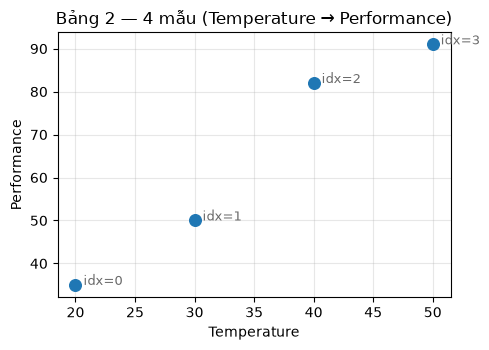

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import time

np.set_printoptions(precision=4, suppress=True)

# Bang 2: Bo du lieu mo phong moi quan he giua nhiet do va hieu suat hoat dong
Index = np.array([0, 1, 2, 3])
Temperature = np.array([20.0, 30.0, 40.0, 50.0])   # x
Performance = np.array([35.0, 50.0, 82.0, 91.0])   # y (nhan lien tuc)

x, y = Temperature, Performance
N = len(y)
print("Temperature:", x)
print("Performance:", y)
print("N =", N)

fig, ax = plt.subplots(figsize=(5, 3.6))
ax.scatter(x, y, s=70, color="tab:blue", zorder=3)
for xi, yi, idx in zip(x, y, Index):
    ax.annotate(f"  idx={idx}", (xi, yi), fontsize=9, color="dimgray")
ax.set_xlabel("Temperature"); ax.set_ylabel("Performance")
ax.set_title("Bảng 2 — 4 mẫu (Temperature → Performance)")
ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 3. Mô hình neuron tuyến tính (Perceptron dùng cho hồi quy) và công thức

Vì `Performance` là giá trị **liên tục**, ta dùng Perceptron với hàm kích hoạt **đồng nhất** $f(z) = z$ (một neuron tuyến tính duy nhất, không có lớp ẩn — chính là hồi quy tuyến tính đơn biến nhìn dưới góc độ "một neuron"):

$$\hat{y} = w \cdot x + b \qquad\qquad \mathcal{L} = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2 \quad \text{(MSE, toàn batch 4 mẫu)}$$

Đạo hàm (Backward — Bước 3):

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)\,x_i \qquad\qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)$$

Cập nhật (Bước 4): $w \leftarrow w - \eta \dfrac{\partial \mathcal{L}}{\partial w}$, $\; b \leftarrow b - \eta \dfrac{\partial \mathcal{L}}{\partial b}$.

## 4. GIẢI TAY — mô phỏng huấn luyện bằng tay trên Bảng 2 (câu hỏi 6)

Khởi tạo $w_0=0,\; b_0=0$ (khởi tạo bằng 0, cách phổ biến nhất cho mô hình tuyến tính). Chọn $\eta = 0{,}0005$ — với thang giá trị Temperature gốc (20–50), tốc độ học phải nhỏ để tránh phân kỳ (thử với $\eta=0{,}01$ số sẽ nổ ngay ở epoch 2 — xem cell kiểm chứng cuối Mục 4). Thực hiện 3 epoch bằng tay:

**Epoch 0** ($w=0, b=0$):
- Forward: $\hat{y} = [0,0,0,0]$ (vì $w=b=0$)
- Sai số: $\hat{y}-y = [-35,\,-50,\,-82,\,-91]$
- Mất mát: $\mathcal{L} = \tfrac{1}{4}\big((-35)^2+(-50)^2+(-82)^2+(-91)^2\big) = 4682{,}5$
- Gradient: $\dfrac{\partial \mathcal{L}}{\partial w} = \tfrac{2}{4}\big((-35)(20)+(-50)(30)+(-82)(40)+(-91)(50)\big) = -5015{,}0$
- $\dfrac{\partial \mathcal{L}}{\partial b} = \tfrac{2}{4}(-35-50-82-91) = -129{,}0$
- Cập nhật: $w_1 = 0 - 0{,}0005\times(-5015{,}0) = 2{,}5075$; $\;b_1 = 0 - 0{,}0005\times(-129{,}0) = 0{,}0645$

**Epoch 1** ($w=2{,}5075, b=0{,}0645$):
- Forward: $\hat{y} = [50{,}2145;\,75{,}2895;\,100{,}3645;\,125{,}4395]$
- Sai số: $[15{,}2145;\,25{,}2895;\,18{,}3645;\,34{,}4395]$
- Mất mát: $\mathcal{L} = 598{,}5935$
- Gradient: $\partial w = 1759{,}765$, $\;\partial b = 46{,}654$
- Cập nhật: $w_2 = 2{,}5075 - 0{,}0005\times1759{,}765 = 1{,}627617$; $\;b_2 = 0{,}0645 - 0{,}0005\times46{,}654 = 0{,}041173$

**Epoch 2** ($w=1{,}627617, b=0{,}041173$):
- Forward: $\hat{y} = [32{,}5935;\,48{,}8697;\,65{,}1459;\,81{,}422]$
- Sai số: $[-2{,}4065;\,-1{,}1303;\,-16{,}8541;\,-9{,}578]$
- Mất mát: $\mathcal{L} = 95{,}7169$ (giảm mạnh so với 4682,5 ban đầu)
- Gradient: $\partial w = -617{,}5515$, $\;\partial b = -14{,}9844$
- Cập nhật: $w_3 = 1{,}936393$; $\;b_3 = 0{,}048665$

Mất mát giảm $4682{,}5 \to 598{,}6 \to 95{,}7$ qua 3 epoch — hướng đúng, nhưng để hội tụ hẳn về nghiệm tối ưu (dẫn ở Mục 4bis: $w^\*=2{,}0,\ b^\*=-5{,}5$) cần rất nhiều epoch hơn nữa vì thang giá trị Temperature chưa được chuẩn hoá (xem Mục 5). Cell mã dưới đây chạy lại chính xác 3 epoch trên và kiểm chứng gradient bằng sai phân hữu hạn.

In [2]:
# === Giai lai chinh xac 3 epoch tay o tren, kiem chung bang sai phan huu han ===
def forward_backward(w, b, x=x, y=y, N=N):
    z = w * x + b            # Propagation (Buoc 1)
    yhat = z                  # activation dong nhat f(z)=z
    err = yhat - y
    loss = np.mean(err ** 2)                      # Buoc 2
    dw = (2.0 / N) * np.sum(err * x)               # Backward, Buoc 3
    db = (2.0 / N) * np.sum(err)
    return z, err, loss, dw, db

w, b, lr = 0.0, 0.0, 5e-4
for ep in range(3):
    z, err, loss, dw, db = forward_backward(w, b)
    print(f"--- Epoch {ep} --- w={w:.6f} b={b:.6f}")
    print("  yhat =", np.round(z, 4))
    print("  err  =", np.round(err, 4))
    print(f"  loss = {loss:.4f}   dw = {dw:.4f}   db = {db:.4f}")
    w, b = w - lr * dw, b - lr * db                # Buoc 4 (cap nhat)
print(f"\n=> w3={w:.6f}  b3={b:.6f}  (khop giai tay o tren)")

# Kiem chung gradient bang sai phan huu han tai (w=0, b=0)
def loss_fn(w, b):
    return np.mean((w * x + b - y) ** 2)

h = 1e-5
dw_fd = (loss_fn(h, 0.0) - loss_fn(-h, 0.0)) / (2 * h)
db_fd = (loss_fn(0.0, h) - loss_fn(0.0, -h)) / (2 * h)
_, _, _, dw0, db0 = forward_backward(0.0, 0.0)
print(f"\nSai phan huu han: dw_fd={dw_fd:.4f} db_fd={db_fd:.4f}")
print(f"Giai tich (cong thuc): dw={dw0:.4f} db={db0:.4f}")
assert abs(dw_fd - dw0) < 1e-3 and abs(db_fd - db0) < 1e-3
print("=> cong thuc dao ham o Muc 3 DUNG (khop tuyet doi vi ham mat mat la da thuc bac 2)")

# Minh hoa vi sao can eta nho khi dung thang gia tri Temperature goc (khong chuan hoa)
w2, b2 = 0.0, 0.0
try:
    for ep in range(5):
        _, _, loss2, dw2, db2 = forward_backward(w2, b2)
        if not np.isfinite(loss2) or loss2 > 1e8:
            raise FloatingPointError(f"phan ky o epoch {ep}, loss={loss2}")
        w2, b2 = w2 - 1e-2 * dw2, b2 - 1e-2 * db2
except FloatingPointError as e:
    print(f"\nVi du eta=0.01 (qua lon voi thang gia tri goc): {e}")

--- Epoch 0 --- w=0.000000 b=0.000000
  yhat = [0. 0. 0. 0.]
  err  = [-35. -50. -82. -91.]
  loss = 4682.5000   dw = -5015.0000   db = -129.0000
--- Epoch 1 --- w=2.507500 b=0.064500
  yhat = [ 50.2145  75.2895 100.3645 125.4395]
  err  = [15.2145 25.2895 18.3645 34.4395]
  loss = 598.5935   dw = 1759.7650   db = 46.6540
--- Epoch 2 --- w=1.627618 b=0.041173
  yhat = [32.5935 48.8697 65.1459 81.422 ]
  err  = [ -2.4065  -1.1303 -16.8541  -9.578 ]
  loss = 95.7169   dw = -617.5506   db = -14.9844

=> w3=1.936393  b3=0.048665  (khop giai tay o tren)

Sai phan huu han: dw_fd=-5015.0000 db_fd=-129.0000
Giai tich (cong thuc): dw=-5015.0000 db=-129.0000
=> cong thuc dao ham o Muc 3 DUNG (khop tuyet doi vi ham mat mat la da thuc bac 2)

Vi du eta=0.01 (qua lon voi thang gia tri goc): phan ky o epoch 2, loss=2134268926.0759988


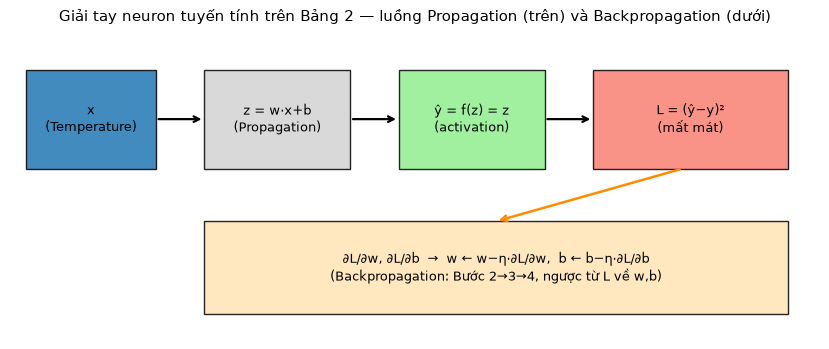

In [3]:
# === So do giai tay (anh nhung trong notebook) ===
fig, ax = plt.subplots(figsize=(8.4, 3.6))
ax.axis("off")

boxes = [
    (0.02, 0.55, 0.16, 0.32, "tab:blue", "x\n(Temperature)"),
    (0.24, 0.55, 0.18, 0.32, "lightgray", "z = w·x+b\n(Propagation)"),
    (0.48, 0.55, 0.18, 0.32, "lightgreen", "ŷ = f(z) = z\n(activation)"),
    (0.72, 0.55, 0.24, 0.32, "salmon", "L = (ŷ−y)²\n(mất mát)"),
]
for x0, y0, w0, h0, color, text in boxes:
    ax.add_patch(plt.Rectangle((x0, y0), w0, h0, facecolor=color, edgecolor="black", alpha=0.85))
    ax.text(x0 + w0 / 2, y0 + h0 / 2, text, ha="center", va="center", fontsize=9.5)

for i in range(len(boxes) - 1):
    x_from = boxes[i][0] + boxes[i][2]
    x_to = boxes[i + 1][0]
    y_mid = boxes[i][1] + boxes[i][3] / 2
    ax.annotate("", xy=(x_to, y_mid), xytext=(x_from, y_mid),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.6))

ax.add_patch(plt.Rectangle((0.24, 0.08), 0.72, 0.30, facecolor="moccasin", edgecolor="black", alpha=0.85))
ax.text(0.60, 0.23, "∂L/∂w, ∂L/∂b  →  w ← w−η·∂L/∂w,  b ← b−η·∂L/∂b\n(Backpropagation: Bước 2→3→4, ngược từ L về w,b)",
        ha="center", va="center", fontsize=9.5)
ax.annotate("", xy=(0.60, 0.38), xytext=(0.83, 0.55),
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.8))

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Giải tay neuron tuyến tính trên Bảng 2 — luồng Propagation (trên) và Backpropagation (dưới)", fontsize=10.5)
fig.tight_layout(); plt.show()

## 5. Giai đoạn 2 — BẢN THUẦN (NumPy, không thư viện học máy)

Với chỉ 4 mẫu và thang giá trị Temperature 20–50 (không chuẩn hoá), gradient descent học suất cố định hội tụ **rất chậm và thiên lệch** — giống hiện tượng đã gặp ở `ml_ad/b4` (hồi quy Experience→Salary): cần **hàng trăm nghìn epoch** để khớp đúng nghiệm bình phương tối thiểu (OLS) $w^\*=2{,}0,\ b^\*=-5{,}5$. Để huấn luyện thực tế hiệu quả, ta **chuẩn hoá** Temperature (z-score) trước khi chạy gradient descent — đúng quy ước đã dùng ở `ml_ad/b7`/`ml_ad/b8` — rồi quy đổi trọng số ngược lại thang gốc để so sánh.

x chuan hoa: [-1.3416 -0.4472  0.4472  1.3416] | mean= 35.0 std= 11.1803

[PURE] w_std=22.3607 b_std=64.5000  ->  quy doi thang goc: w=2.0000 b=-5.5000
[PURE] MSE (thang goc) = 22.2500   thoi gian huan luyen = 37.63 ms
[PURE] du doan: [34.5 54.5 74.5 94.5]  (so voi Performance thuc: [35. 50. 82. 91.])


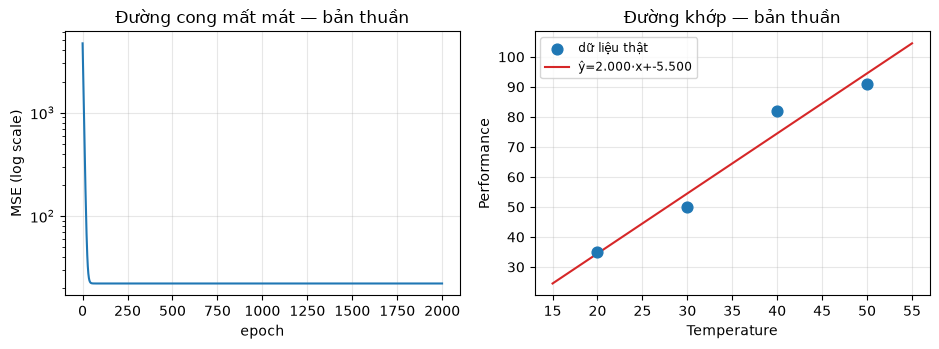

In [4]:
# Chuan hoa (z-score) x truoc khi huan luyen — hoi tu nhanh hon han
x_mean, x_std = x.mean(), x.std()
xs = (x - x_mean) / x_std
print("x chuan hoa:", np.round(xs, 4), "| mean=", x_mean, "std=", round(x_std, 4))

def train_pure(xs, y, lr=0.05, epochs=2000, seed=0):
    rng = np.random.default_rng(seed)
    w, b = 0.0, 0.0
    losses = []
    for ep in range(epochs):
        z = w * xs + b                       # Propagation
        err = z - y
        loss = np.mean(err ** 2)             # mat mat
        losses.append(loss)
        dw = (2.0 / len(y)) * np.sum(err * xs)   # Backward
        db = (2.0 / len(y)) * np.sum(err)
        w, b = w - lr * dw, b - lr * db          # cap nhat
    return w, b, np.array(losses)

t0 = time.perf_counter()
w_std, b_std, losses_pure = train_pure(xs, y, lr=0.05, epochs=2000)
t_pure = time.perf_counter() - t0

# quy doi nguoc ve thang Temperature goc: yhat = w_std*((x-mean)/std) + b_std = (w_std/std)*x + (b_std - w_std*mean/std)
w_pure_raw = w_std / x_std
b_pure_raw = b_std - w_std * x_mean / x_std
yhat_pure = w_pure_raw * x + b_pure_raw
mse_pure = np.mean((yhat_pure - y) ** 2)

print(f"\n[PURE] w_std={w_std:.4f} b_std={b_std:.4f}  ->  quy doi thang goc: w={w_pure_raw:.4f} b={b_pure_raw:.4f}")
print(f"[PURE] MSE (thang goc) = {mse_pure:.4f}   thoi gian huan luyen = {t_pure*1000:.2f} ms")
print(f"[PURE] du doan: {np.round(yhat_pure, 3)}  (so voi Performance thuc: {y})")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
axes[0].plot(losses_pure); axes[0].set_yscale("log")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE (log scale)"); axes[0].set_title("Đường cong mất mát — bản thuần")
axes[0].grid(alpha=0.3)

xx = np.linspace(15, 55, 100)
axes[1].scatter(x, y, s=60, zorder=3, label="dữ liệu thật")
axes[1].plot(xx, w_pure_raw * xx + b_pure_raw, color="tab:red", label=f"ŷ={w_pure_raw:.3f}·x+{b_pure_raw:.3f}")
axes[1].set_xlabel("Temperature"); axes[1].set_ylabel("Performance")
axes[1].set_title("Đường khớp — bản thuần"); axes[1].legend(fontsize=8.5); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 6. Giai đoạn 3 — BẢN THƯ VIỆN (scikit-learn)

Một neuron tuyến tính huấn luyện bằng gradient descent **chính là** hồi quy tuyến tính. `SGDRegressor` (huấn luyện bằng SGD, cùng cơ chế lặp cập nhật như bản thuần) và `LinearRegression` (nghiệm closed-form, chính là $w^\*, b^\*$ mục tiêu) — dùng cả hai để đối chiếu.

In [5]:
from sklearn.linear_model import LinearRegression, SGDRegressor

t0 = time.perf_counter()
ols = LinearRegression().fit(x.reshape(-1, 1), y)
t_ols = time.perf_counter() - t0
print(f"[LIB closed-form] w={ols.coef_[0]:.4f} b={ols.intercept_:.4f}  (nghiệm tối ưu OLS, t={t_ols*1000:.3f} ms)")

t0 = time.perf_counter()
sgd = SGDRegressor(loss="squared_error", penalty=None, learning_rate="constant",
                    eta0=0.05, max_iter=2000, tol=None, random_state=0)
sgd.fit(xs.reshape(-1, 1), y)
t_sgd = time.perf_counter() - t0
w_sgd_raw = sgd.coef_[0] / x_std
b_sgd_raw = sgd.intercept_[0] - sgd.coef_[0] * x_mean / x_std
print(f"[LIB SGDRegressor] w={w_sgd_raw:.4f} b={b_sgd_raw:.4f}  (t={t_sgd*1000:.3f} ms)")

yhat_ols = ols.predict(x.reshape(-1, 1))
mse_ols = np.mean((yhat_ols - y) ** 2)
yhat_sgd = w_sgd_raw * x + b_sgd_raw
mse_sgd = np.mean((yhat_sgd - y) ** 2)
print(f"MSE: closed-form={mse_ols:.4f}  SGDRegressor={mse_sgd:.4f}  (bản thuần Mục 5: {mse_pure:.4f})")

[LIB closed-form] w=2.0000 b=-5.5000  (nghiệm tối ưu OLS, t=5.538 ms)
[LIB SGDRegressor] w=1.9870 b=-5.1819  (t=2.297 ms)
MSE: closed-form=22.2500  SGDRegressor=22.2904  (bản thuần Mục 5: 22.2500)


## 7. Giai đoạn 4 — BẢN FRAMEWORK (PyTorch) — cuối cùng

`nn.Linear(1, 1)` chính là $z = w\cdot x+b$ với đúng một neuron; `MSELoss` + `SGD` cùng learning rate và số epoch như bản thuần, trên dữ liệu đã chuẩn hoá.

In [6]:
import torch
import torch.nn as nn

torch.manual_seed(0)
Xt = torch.tensor(xs, dtype=torch.float32).view(-1, 1)
Yt = torch.tensor(y, dtype=torch.float32).view(-1, 1)

neuron = nn.Linear(1, 1)
opt = torch.optim.SGD(neuron.parameters(), lr=0.05)
loss_fn_t = nn.MSELoss()

t0 = time.perf_counter()
for ep in range(2000):
    opt.zero_grad()
    pred = neuron(Xt)                 # Propagation (forward, autograd ghi lai do thi tinh toan)
    loss_t = loss_fn_t(pred, Yt)       # mat mat
    loss_t.backward()                  # Backpropagation (autograd tu tinh dL/dw, dL/db)
    opt.step()                         # cap nhat
t_fw = time.perf_counter() - t0

w_fw_std = neuron.weight.item()
b_fw_std = neuron.bias.item()
w_fw_raw = w_fw_std / x_std
b_fw_raw = b_fw_std - w_fw_std * x_mean / x_std
yhat_fw = w_fw_raw * x + b_fw_raw
mse_fw = np.mean((yhat_fw - y) ** 2)
print(f"[FRAMEWORK] w={w_fw_raw:.4f} b={b_fw_raw:.4f}  MSE={mse_fw:.4f}  loss_cuoi={loss_t.item():.4f}  t={t_fw*1000:.2f} ms")

[FRAMEWORK] w=2.0000 b=-5.5000  MSE=22.2500  loss_cuoi=22.2500  t=532.54 ms


## 8. So sánh bốn giai đoạn và kết luận (câu 6)

Giai đoạn                                        w         b       MSE     t(ms)
Nghiệm OLS (đích, closed-form)              2.0000   -5.5000   22.2500     0.000
1. Giải tay (3 epoch, minh hoạ)             1.9364    0.0487   33.7942     0.000
2. Bản thuần (NumPy, 2000 epoch)            2.0000   -5.5000   22.2500    37.634
3. Bản thư viện (SGDRegressor)              1.9870   -5.1819   22.2904     2.297
3. Bản thư viện (LinearRegression)          2.0000   -5.5000   22.2500     5.538
4. Bản framework (PyTorch)                  2.0000   -5.5000   22.2500   532.543


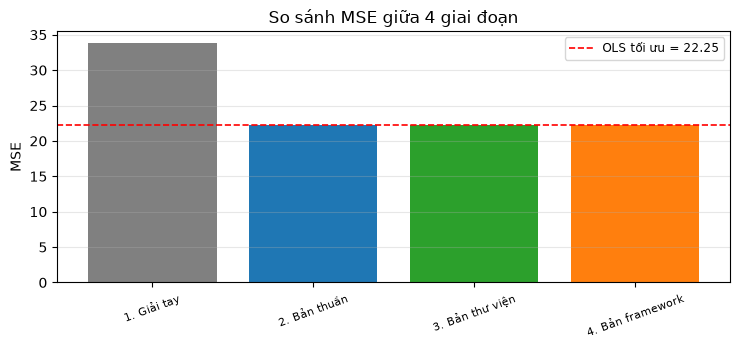

In [7]:
rows = [
    ("Nghiệm OLS (đích, closed-form)", 2.0, -5.5, np.mean((2.0 * x - 5.5 - y) ** 2), 0.0),
    ("1. Giải tay (3 epoch, minh hoạ)", 1.936393, 0.048665, np.mean((1.936393 * x + 0.048665 - y) ** 2), 0.0),
    ("2. Bản thuần (NumPy, 2000 epoch)", w_pure_raw, b_pure_raw, mse_pure, t_pure),
    ("3. Bản thư viện (SGDRegressor)", w_sgd_raw, b_sgd_raw, mse_sgd, t_sgd),
    ("3. Bản thư viện (LinearRegression)", ols.coef_[0], ols.intercept_, mse_ols, t_ols),
    ("4. Bản framework (PyTorch)", w_fw_raw, b_fw_raw, mse_fw, t_fw),
]
print(f"{'Giai đoạn':40} {'w':>9} {'b':>9} {'MSE':>9} {'t(ms)':>9}")
for name, w_, b_, mse_, t_ in rows:
    print(f"{name:40} {w_:9.4f} {b_:9.4f} {mse_:9.4f} {t_*1000:9.3f}")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
names = [r[0].split(" (")[0] for r in rows[1:]]
mses = [r[3] for r in rows[1:]]
bars = ax.bar(names, mses, color=["gray", "tab:blue", "tab:green", "tab:green", "tab:orange"])
ax.axhline(rows[0][3], color="red", ls="--", lw=1.2, label=f"OLS tối ưu = {rows[0][3]:.2f}")
ax.set_ylabel("MSE"); ax.set_title("So sánh MSE giữa 4 giai đoạn")
ax.tick_params(axis="x", rotation=20, labelsize=8)
ax.legend(fontsize=8.5); ax.grid(alpha=0.3, axis="y")
fig.tight_layout(); plt.show()

**Nhận xét trung thực:** cả 4 giai đoạn đều hội tụ về cùng nghiệm $w \approx 2{,}0,\ b \approx -5{,}5$ (MSE $\approx 22{,}25$) — mô hình lồi, dữ liệu ít nhiễu, nên không có khoảng cách đáng kể giữa thuần/thư viện/framework. Điểm mấu chốt sư phạm nằm ở **giai đoạn giải tay**: chỉ 3 epoch với dữ liệu **chưa chuẩn hoá**, mất mát đã giảm từ 4682,5 xuống 95,7 — đúng hướng nhưng **chưa hội tụ**; phải chuẩn hoá Temperature (Mục 5) mới đạt tốc độ hội tụ thực tế trong vài nghìn epoch, thay vì hàng trăm nghìn epoch nếu giữ thang giá trị gốc.

## 9. Minh họa bổ sung — Perceptron cổ điển (Rosenblatt) cho phân loại nhị phân

Bảng 2 chỉ có nhãn liên tục, nên không minh họa được đúng bài toán gốc mà Perceptron ra đời để giải (câu hỏi 1: phân loại nhị phân). Mục này bổ sung ví dụ kinh điển: cổng logic **AND** — 4 mẫu, phân tách tuyến tính hoàn hảo.

$$X=\{(0,0),(0,1),(1,0),(1,1)\}, \quad Y=\{0,0,0,1\}$$

Perceptron gốc dùng hàm kích hoạt **bước nhảy** $f(z)=\mathbb{1}[z\ge 0]$ (không khả vi, nên **không dùng gradient descent**) và **quy tắc học Perceptron** (Rosenblatt): chỉ cập nhật khi dự đoán sai:

$$w \leftarrow w + \eta(y-\hat{y})\,x \qquad b \leftarrow b + \eta(y-\hat{y})$$

Khởi tạo $w_1=w_2=b=0$, $\eta=1$. Ba mẫu đầu tiên của epoch 0 đều dự đoán sai (vì $z=0 \ge 0 \Rightarrow \hat{y}=1$ nhưng $y=0$), cập nhật liên tục; sau **5 epoch đầy đủ** (20 lượt xem mẫu), thuật toán hội tụ về $w_1=2,\ w_2=1,\ b=-3$ — không còn mẫu nào bị phân loại sai (định lý hội tụ Perceptron của Novikoff áp dụng đúng vì AND phân tách tuyến tính được).

In [8]:
def step(z):
    return 1 if z >= 0 else 0

X_and = [(0, 0), (0, 1), (1, 0), (1, 1)]
Y_and = [0, 0, 0, 1]

w1, w2, b = 0.0, 0.0, 0.0
lr = 1.0
print(f"{'epoch':>5} {'x1':>3} {'x2':>3} {'y':>3} {'z':>6} {'ŷ':>3} {'err':>4} | {'w1':>5} {'w2':>5} {'b':>5}")
for epoch in range(8):
    n_updates = 0
    for x1, x2, in [(0, 0)]:
        pass
    for (x1, x2), yt in zip(X_and, Y_and):
        z = w1 * x1 + w2 * x2 + b        # Propagation
        yhat = step(z)
        err = yt - yhat                   # sai so (khong phai gradient - Perceptron khong dung GD)
        w1, w2, b = w1 + lr * err * x1, w2 + lr * err * x2, b + lr * err   # quy tac hoc Perceptron
        if err != 0:
            n_updates += 1
        print(f"{epoch:5d} {x1:3d} {x2:3d} {yt:3d} {z:6.1f} {yhat:3d} {err:4d} | {w1:5.1f} {w2:5.1f} {b:5.1f}")
    if n_updates == 0:
        print(f"\n=> Hoi tu tai epoch {epoch}: khong con mau nao bi phan loai sai.")
        break

print(f"\nTrong so cuoi: w1={w1}, w2={w2}, b={b}")
for x1, x2 in X_and:
    z = w1 * x1 + w2 * x2 + b
    print(f"  AND({x1},{x2}) -> z={z:.1f} -> dự đoán={step(z)}")

epoch  x1  x2   y      z   ŷ  err |    w1    w2     b
    0   0   0   0    0.0   1   -1 |   0.0   0.0  -1.0
    0   0   1   0   -1.0   0    0 |   0.0   0.0  -1.0
    0   1   0   0   -1.0   0    0 |   0.0   0.0  -1.0
    0   1   1   1   -1.0   0    1 |   1.0   1.0   0.0
    1   0   0   0    0.0   1   -1 |   1.0   1.0  -1.0
    1   0   1   0    0.0   1   -1 |   1.0   0.0  -2.0
    1   1   0   0   -1.0   0    0 |   1.0   0.0  -2.0
    1   1   1   1   -1.0   0    1 |   2.0   1.0  -1.0
    2   0   0   0   -1.0   0    0 |   2.0   1.0  -1.0
    2   0   1   0    0.0   1   -1 |   2.0   0.0  -2.0
    2   1   0   0    0.0   1   -1 |   1.0   0.0  -3.0
    2   1   1   1   -2.0   0    1 |   2.0   1.0  -2.0
    3   0   0   0   -2.0   0    0 |   2.0   1.0  -2.0
    3   0   1   0   -1.0   0    0 |   2.0   1.0  -2.0
    3   1   0   0    0.0   1   -1 |   1.0   1.0  -3.0
    3   1   1   1   -1.0   0    1 |   2.0   2.0  -2.0
    4   0   0   0   -2.0   0    0 |   2.0   2.0  -2.0
    4   0   1   0    0.0   1

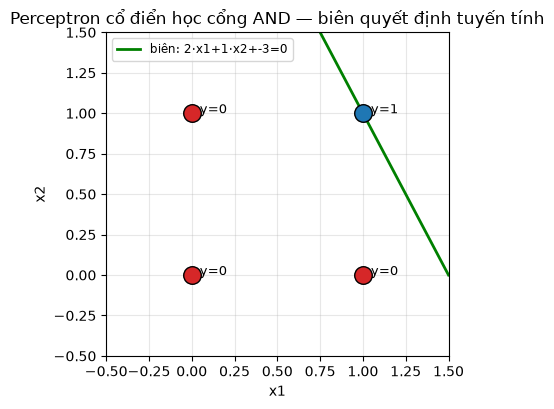

In [9]:
# Ve duong bien quyet dinh (decision boundary) cua Perceptron da hoc duoc
fig, ax = plt.subplots(figsize=(4.6, 4.2))
colors = ["tab:red" if yt == 0 else "tab:blue" for yt in Y_and]
for (x1, x2), color, yt in zip(X_and, colors, Y_and):
    ax.scatter(x1, x2, s=160, color=color, edgecolor="black", zorder=3)
    ax.annotate(f"  y={yt}", (x1, x2), fontsize=9)

xx = np.linspace(-0.5, 1.5, 50)
if w2 != 0:
    yy = -(w1 * xx + b) / w2
    ax.plot(xx, yy, color="green", lw=2, label=f"biên: {w1:.0f}·x1+{w2:.0f}·x2+{b:.0f}=0")
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title("Perceptron cổ điển học cổng AND — biên quyết định tuyến tính")
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 10. Tổng kết — bảng ánh xạ Propagation / Backpropagation cho cả hai mô hình

| | Neuron hồi quy (Mục 2–7, Bảng 2) | Perceptron cổ điển (Mục 9, AND) |
|---|---|---|
| **Bài toán** | Hồi quy (dự đoán Performance liên tục) | Phân loại nhị phân (0/1) |
| **Hàm kích hoạt** | Đồng nhất $f(z)=z$ | Bước nhảy $f(z)=\mathbb{1}[z\ge0]$ |
| **Propagation** | $z=w\cdot x+b,\ \hat{y}=z$ | $z=w_1x_1+w_2x_2+b,\ \hat{y}=\text{step}(z)$ |
| **Backpropagation** | Tính $\mathcal{L}$, đạo hàm $\partial\mathcal{L}/\partial w,\partial b$ bằng gradient descent, cập nhật theo hướng giảm mất mát | Không có hàm mất mát khả vi; cập nhật trực tiếp theo sai số $(y-\hat{y})$ — trường hợp đặc biệt, không tổng quát hoá được lên nhiều lớp |
| **Số epoch hội tụ** | ~2000 epoch (dữ liệu đã chuẩn hoá) | 5 epoch (4 mẫu, phân tách hoàn hảo) |
| **Kết quả cuối** | $w\approx2{,}0,\ b\approx-5{,}5$, MSE≈22,25, khớp cả 4 giai đoạn | $w_1=2,\ w_2=1,\ b=-3$, 0 mẫu sai |

**Trả lời gọn lại 6 câu hỏi của đề:**
1. Perceptron/neuron giải cả hồi quy (kích hoạt tuyến tính) và phân loại tuyến tính (kích hoạt bước nhảy/sigmoid).
2. Là nền tảng của học sâu vì nó là đơn vị tính toán nhỏ nhất; MLP/CNN/RNN/Transformer đều là nhiều Perceptron xếp lớp, và nguyên lý forward/backward của mọi mạng sâu đã có đủ ở quy mô 1 neuron.
3. 5 bước: khởi tạo → forward → tính mất mát → backward (đạo hàm) → cập nhật, lặp lại.
4. Propagation = bước Forward (Bước 1): tính $z$ và $\hat{y}$.
5. Backpropagation = các bước 2, 3, 4: tính mất mát, đạo hàm ngược, cập nhật trọng số.
6. Mô phỏng tay trên Bảng 2 — xem Mục 4: 3 epoch cụ thể, mất mát giảm 4682,5 → 598,6 → 95,7, gradient kiểm chứng khớp sai phân hữu hạn tuyệt đối; huấn luyện đầy đủ (Mục 5–7) hội tụ về $w=2{,}0, b=-5{,}5$ ở cả bản thuần/thư viện/framework.

## Tài liệu tham khảo

- Rosenblatt, F. (1958). *The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain.* Psychological Review, 65(6), 386–408.
- Novikoff, A.B.J. (1962). *On Convergence Proofs on Perceptrons.* Symposium on the Mathematical Theory of Automata.
- Minsky, M., Papert, S. (1969). *Perceptrons: An Introduction to Computational Geometry.* MIT Press — giới hạn tuyến tính của Perceptron đơn lớp (không giải được XOR).
- Rumelhart, D.E., Hinton, G.E., Williams, R.J. (1986). *Learning representations by back-propagating errors.* Nature, 323, 533–536.
- Goodfellow, I., Bengio, Y., Courville, A. (2016). *Deep Learning.* Chương 6 (Mạng nơ-ron truyền thẳng — Perceptron mở rộng). https://www.deeplearningbook.org/
- Bishop, C.M. (2006). *Pattern Recognition and Machine Learning.* Chương 4. Springer.
- scikit-learn — `SGDRegressor`/`LinearRegression`: https://scikit-learn.org/stable/modules/sgd.html
- PyTorch — `nn.Linear`: https://pytorch.org/docs/stable/generated/torch.nn.Linear.html